# Naive Bayes: Simple, Fast, and Surprisingly Effective

**Learning Objectives:**
- Understand **Bayes' theorem** and how it applies to classification
- Learn the **naive independence assumption** and why it often works anyway
- Implement **Gaussian**, **Multinomial**, and **Bernoulli** Naive Bayes from scratch
- Understand **Laplace smoothing** for handling unseen features
- Compare Naive Bayes with other classifiers and know when to use it

By the end of this notebook, you'll have **deep intuitions** about Naive Bayes — a foundational probabilistic classifier that connects probability theory directly to classification.


## Part 1: Why Naive Bayes Matters

Naive Bayes is one of the most **elegant** algorithms in machine learning. It's important because:

1. **Connects probability to classification** — Direct application of Bayes' theorem
2. **Extremely fast** — Training is O(n·d), prediction is O(d) where n=samples, d=features
3. **Works well with small data** — Doesn't need massive datasets
4. **Handles high-dimensional data** — Excels at text classification (thousands of features)
5. **Provides probability estimates** — Not just class labels, but confidence scores
6. **Strong baseline** — Often surprisingly competitive with complex models

### Real-World Applications

- **Spam filtering** — The classic application (Gmail's first spam filter!)
- **Sentiment analysis** — Positive/negative review classification
- **Document categorization** — News articles, support tickets
- **Medical diagnosis** — Given symptoms, predict disease
- **Recommendation systems** — Content-based filtering


## Part 2: Setup

### Configuration

All hyperparameters in one place for easy experimentation.


In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Data
    'n_samples': 500,  # Number of samples for synthetic datasets
    'test_size': 0.2,  # Fraction of data for testing
    
    # Naive Bayes
    'laplace_smoothing': 1.0,  # Laplace smoothing parameter (alpha)
    'var_smoothing': 1e-9,  # Variance smoothing for Gaussian NB
}


### Random Seed & Imports


In [2]:
from aiml_notebooks import set_seed
import numpy as np

set_seed(CONFIG['seed'])

print(f"✓ Seed set to {CONFIG['seed']} for reproducibility")


✓ Seed set to 42 for reproducibility


In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


## Part 3: Bayes' Theorem — The Foundation

Naive Bayes is built on **Bayes' theorem**, which describes how to update beliefs given new evidence:

$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

Where:
- $P(C|X)$ = **Posterior** — Probability of class $C$ given features $X$ (what we want!)
- $P(X|C)$ = **Likelihood** — Probability of seeing features $X$ if we know class is $C$
- $P(C)$ = **Prior** — Probability of class $C$ before seeing any features
- $P(X)$ = **Evidence** — Probability of features $X$ (normalization constant)

### Intuitive Example: Medical Diagnosis

Suppose we want to diagnose whether a patient has the flu based on symptoms:

- **Prior $P(\text{flu})$**: Base rate of flu in population (e.g., 5%)
- **Likelihood $P(\text{fever}|\text{flu})$**: Probability of fever given flu (e.g., 90%)
- **Evidence $P(\text{fever})$**: Overall probability of having fever (e.g., 20%)

Then: $P(\text{flu}|\text{fever}) = \frac{0.90 \times 0.05}{0.20} = 0.225 = 22.5\%$

Having a fever increases our belief in flu from 5% → 22.5%!


In [4]:
# Let's visualize Bayes' theorem with the medical example

def bayes_theorem(p_disease, p_symptom_given_disease, p_symptom_given_no_disease):
    """Calculate P(disease | symptom) using Bayes' theorem."""
    # P(symptom) = P(symptom|disease)*P(disease) + P(symptom|no_disease)*P(no_disease)
    p_symptom = p_symptom_given_disease * p_disease + p_symptom_given_no_disease * (1 - p_disease)
    
    # Bayes' theorem
    p_disease_given_symptom = (p_symptom_given_disease * p_disease) / p_symptom
    return p_disease_given_symptom

# Flu diagnosis example
p_flu = 0.05  # Prior: 5% of population has flu
p_fever_given_flu = 0.90  # 90% of flu patients have fever
p_fever_given_no_flu = 0.15  # 15% of healthy people also have fever (other causes)

p_flu_given_fever = bayes_theorem(p_flu, p_fever_given_flu, p_fever_given_no_flu)

print("🏥 Medical Diagnosis Example: Flu Detection")
print("=" * 50)
print(f"Prior P(flu):                    {p_flu:.1%}")
print(f"P(fever | flu):                  {p_fever_given_flu:.1%}")
print(f"P(fever | no flu):               {p_fever_given_no_flu:.1%}")
print("-" * 50)
print(f"Posterior P(flu | fever):        {p_flu_given_fever:.1%}")
print()
print(f"💡 Fever increases flu probability: {p_flu:.1%} → {p_flu_given_fever:.1%}")
print(f"   That's a {p_flu_given_fever/p_flu:.1f}x increase!")


🏥 Medical Diagnosis Example: Flu Detection
Prior P(flu):                    5.0%
P(fever | flu):                  90.0%
P(fever | no flu):               15.0%
--------------------------------------------------
Posterior P(flu | fever):        24.0%

💡 Fever increases flu probability: 5.0% → 24.0%
   That's a 4.8x increase!


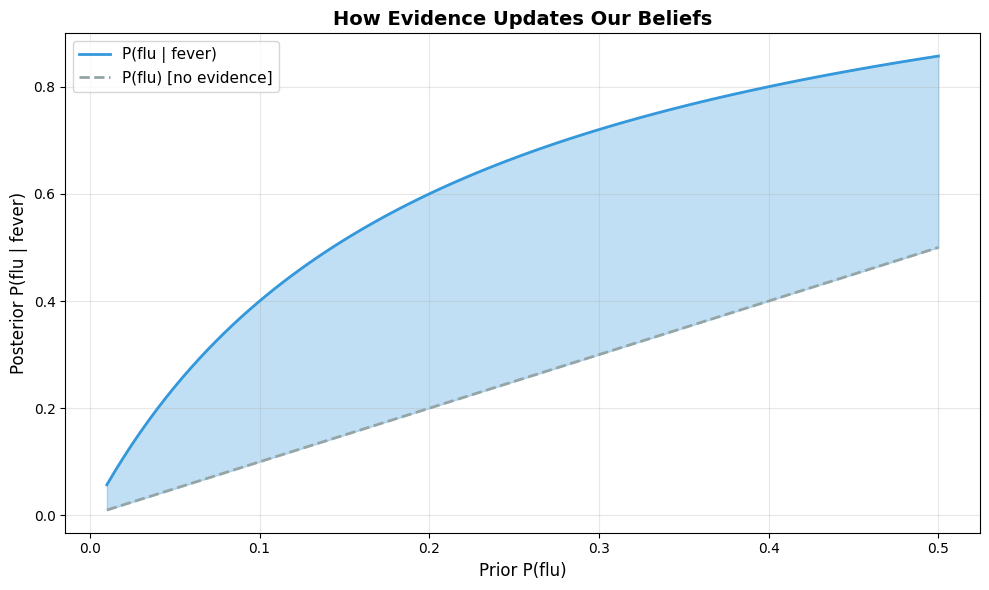

📊 The blue shaded area shows how much fever evidence shifts our belief upward.


In [5]:
# Visualize how posterior changes with different priors
priors = np.linspace(0.01, 0.5, 100)
posteriors = [bayes_theorem(p, p_fever_given_flu, p_fever_given_no_flu) for p in priors]

plt.figure(figsize=(10, 6))
plt.plot(priors, posteriors, linewidth=2, color='#3498db', label='P(flu | fever)')
plt.plot(priors, priors, linewidth=2, linestyle='--', color='#95a5a6', label='P(flu) [no evidence]')
plt.fill_between(priors, priors, posteriors, alpha=0.3, color='#3498db')
plt.xlabel('Prior P(flu)', fontsize=12)
plt.ylabel('Posterior P(flu | fever)', fontsize=12)
plt.title('How Evidence Updates Our Beliefs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 The blue shaded area shows how much fever evidence shifts our belief upward.")


## Part 4: The "Naive" Assumption — Feature Independence

For classification with multiple features $X = (x_1, x_2, ..., x_d)$, we need to compute:

$$P(C|X) = P(C|x_1, x_2, ..., x_d) \propto P(x_1, x_2, ..., x_d | C) \cdot P(C)$$

The problem: estimating $P(x_1, x_2, ..., x_d | C)$ requires exponentially many samples!

### The Naive Solution: Assume Independence

The **naive** assumption: all features are **conditionally independent** given the class:

$$P(x_1, x_2, ..., x_d | C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_d|C) = \prod_{i=1}^{d} P(x_i|C)$$

This simplifies our classifier to:

$$P(C|X) \propto P(C) \prod_{i=1}^{d} P(x_i|C)$$

### Why "Naive"?

The assumption is almost **always wrong**! Features are usually correlated:
- In spam detection: "buy" and "cheap" often appear together
- In medical diagnosis: fever and cough are correlated

### Why It Still Works

Despite violating the independence assumption:
1. **We only need the ranking to be correct**, not the exact probabilities
2. **Dependencies often cancel out** when comparing classes
3. **More features = more evidence**, even if dependencies exist
4. **Regularization effect**: The naive assumption acts as a form of regularization


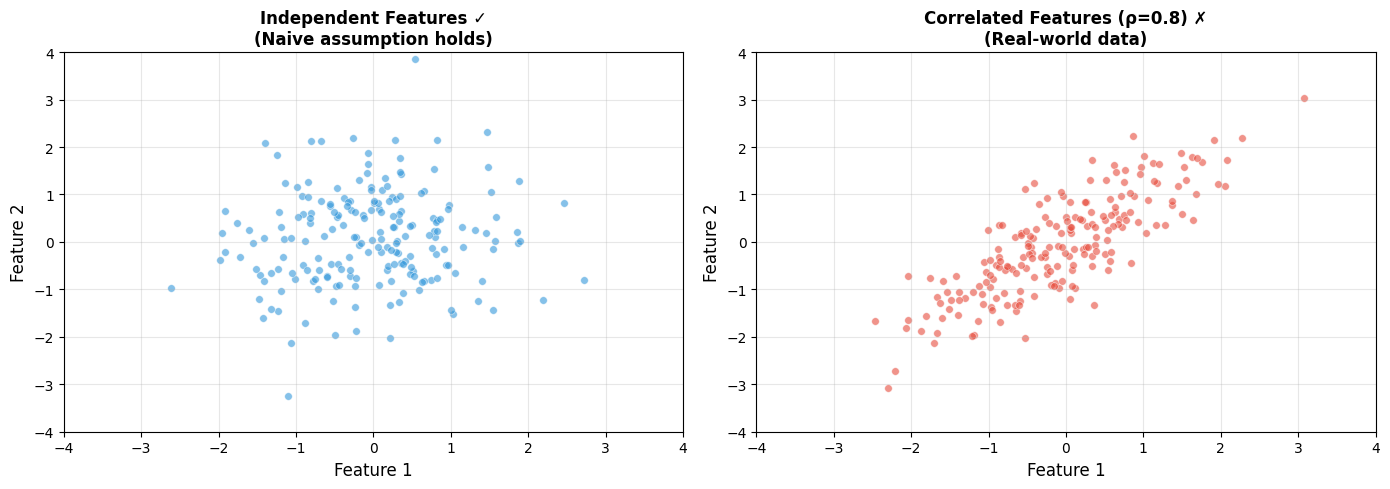

💡 Key Insight: Naive Bayes assumes LEFT, but real data often looks like RIGHT.
   Surprisingly, it still works well for classification!


In [6]:
# Demonstrate the independence assumption with a visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Independent features
np.random.seed(CONFIG['seed'])
n = 200
x1_ind = np.random.randn(n)
x2_ind = np.random.randn(n)

axes[0].scatter(x1_ind, x2_ind, alpha=0.6, c='#3498db', s=30, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title('Independent Features ✓\n(Naive assumption holds)', fontsize=12, fontweight='bold')
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(-4, 4)
axes[0].grid(True, alpha=0.3)

# Right: Correlated features
correlation = 0.8
x1_corr = np.random.randn(n)
x2_corr = correlation * x1_corr + np.sqrt(1 - correlation**2) * np.random.randn(n)

axes[1].scatter(x1_corr, x2_corr, alpha=0.6, c='#e74c3c', s=30, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title(f'Correlated Features (ρ={correlation}) ✗\n(Real-world data)', fontsize=12, fontweight='bold')
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(-4, 4)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Key Insight: Naive Bayes assumes LEFT, but real data often looks like RIGHT.")
print("   Surprisingly, it still works well for classification!")


## Part 5: Gaussian Naive Bayes — For Continuous Features

When features are **continuous** (real numbers), we model $P(x_i|C)$ as a Gaussian (normal) distribution:

$$P(x_i|C=c) = \frac{1}{\sqrt{2\pi\sigma_{c,i}^2}} \exp\left(-\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^2}\right)$$

Where:
- $\mu_{c,i}$ = mean of feature $i$ for class $c$ (estimated from training data)
- $\sigma_{c,i}^2$ = variance of feature $i$ for class $c$

### Training Gaussian NB

Training is incredibly simple:
1. For each class $c$, calculate $P(c) = \frac{\text{count}(c)}{N}$
2. For each feature $i$ and class $c$, calculate mean $\mu_{c,i}$ and variance $\sigma_{c,i}^2$

That's it! No optimization, no iteration — just counting and averaging.


In [7]:
class GaussianNaiveBayesScratch:
    """Gaussian Naive Bayes classifier implemented from scratch."""
    
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.priors_ = None  # P(C) for each class
        self.means_ = None   # Mean of each feature for each class
        self.vars_ = None    # Variance of each feature for each class
    
    def fit(self, X, y):
        """Train the classifier by computing means and variances."""
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        # Initialize parameters
        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.vars_ = np.zeros((n_classes, n_features))
        
        # Calculate statistics for each class
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]  # Samples belonging to class c
            
            self.priors_[idx] = len(X_c) / n_samples  # Prior P(C)
            self.means_[idx] = X_c.mean(axis=0)        # Mean for each feature
            self.vars_[idx] = X_c.var(axis=0) + self.var_smoothing  # Variance + smoothing
        
        return self
    
    def _gaussian_likelihood(self, x, mean, var):
        """Calculate Gaussian probability density."""
        # log(P(x|C)) for numerical stability
        return -0.5 * (np.log(2 * np.pi * var) + ((x - mean) ** 2) / var)
    
    def predict_log_proba(self, X):
        """Calculate log probabilities for each class."""
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        log_proba = np.zeros((n_samples, n_classes))
        
        for idx, c in enumerate(self.classes_):
            # Log prior
            log_prior = np.log(self.priors_[idx])
            
            # Sum of log likelihoods for each feature (naive independence!)
            log_likelihood = np.sum(
                self._gaussian_likelihood(X, self.means_[idx], self.vars_[idx]),
                axis=1
            )
            
            log_proba[:, idx] = log_prior + log_likelihood
        
        return log_proba
    
    def predict(self, X):
        """Predict class labels."""
        log_proba = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_proba, axis=1)]
    
    def score(self, X, y):
        """Calculate accuracy."""
        return np.mean(self.predict(X) == y)

print("✓ GaussianNaiveBayesScratch class defined")


✓ GaussianNaiveBayesScratch class defined


In [8]:
# Test on Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=CONFIG['test_size'], random_state=CONFIG['seed']
)

# Our implementation
gnb_scratch = GaussianNaiveBayesScratch(var_smoothing=CONFIG['var_smoothing'])
gnb_scratch.fit(X_train, y_train)
scratch_acc = gnb_scratch.score(X_test, y_test)

# Sklearn implementation
gnb_sklearn = GaussianNB(var_smoothing=CONFIG['var_smoothing'])
gnb_sklearn.fit(X_train, y_train)
sklearn_acc = gnb_sklearn.score(X_test, y_test)

print("Gaussian Naive Bayes on Iris Dataset")
print("=" * 45)
print(f"Our implementation accuracy:     {scratch_acc:.4f}")
print(f"Sklearn implementation accuracy: {sklearn_acc:.4f}")
print(f"Match: {'✓' if np.isclose(scratch_acc, sklearn_acc) else '✗'}")


Gaussian Naive Bayes on Iris Dataset
Our implementation accuracy:     1.0000
Sklearn implementation accuracy: 1.0000
Match: ✓


### Visualizing Gaussian NB Decision Boundaries

Let's see how Gaussian NB creates decision boundaries:


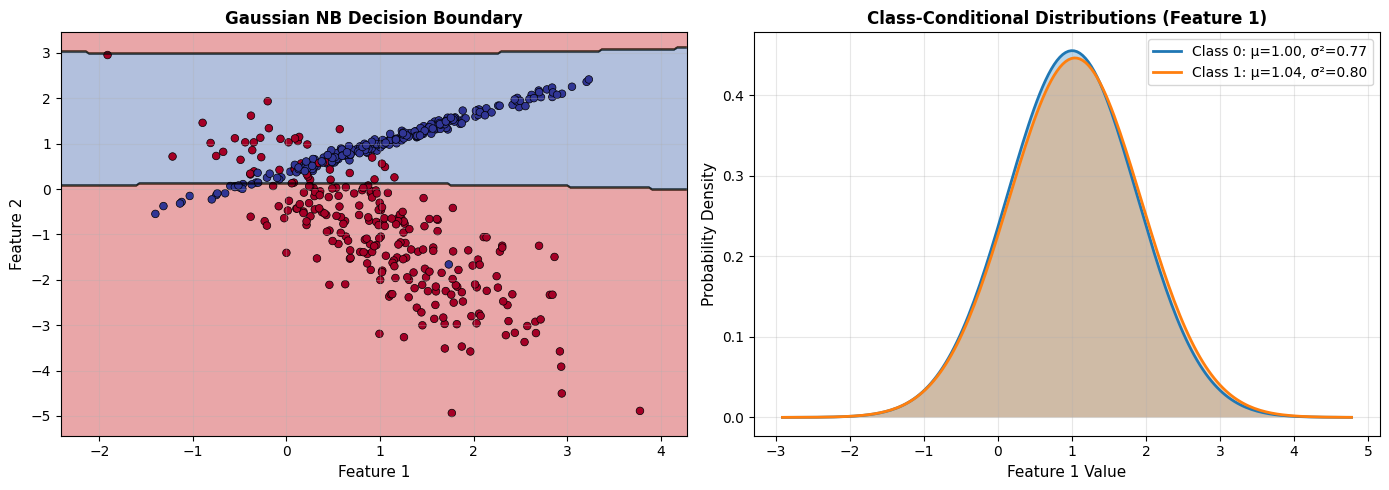

💡 Key Insight: Gaussian NB creates smooth, curved decision boundaries
   based on the Gaussian distributions learned for each class.


In [9]:
def plot_decision_boundary_nb(model, X, y, title="Decision Boundary", ax=None):
    """Plot decision boundary for 2D classification."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    # Get predictions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)
    
    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                         s=30, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    return ax

# Generate 2D data for visualization
X_2d, y_2d = make_classification(
    n_samples=CONFIG['n_samples'],
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=CONFIG['seed']
)

# Train and visualize
gnb_2d = GaussianNB()
gnb_2d.fit(X_2d, y_2d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary
plot_decision_boundary_nb(gnb_2d, X_2d, y_2d, 'Gaussian NB Decision Boundary', axes[0])

# Show the Gaussian distributions for each feature/class
axes[1].set_title('Class-Conditional Distributions (Feature 1)', fontsize=12, fontweight='bold')
x_range = np.linspace(X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1, 200)

for c in [0, 1]:
    mean = gnb_2d.theta_[c, 0]
    var = gnb_2d.var_[c, 0]
    pdf = (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x_range - mean) ** 2) / (2 * var))
    label = f'Class {c}: μ={mean:.2f}, σ²={var:.2f}'
    axes[1].plot(x_range, pdf, linewidth=2, label=label)
    axes[1].fill_between(x_range, pdf, alpha=0.3)

axes[1].set_xlabel('Feature 1 Value', fontsize=11)
axes[1].set_ylabel('Probability Density', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Key Insight: Gaussian NB creates smooth, curved decision boundaries")
print("   based on the Gaussian distributions learned for each class.")


## Part 6: Multinomial Naive Bayes — For Count Data

When features are **counts** (word frequencies, event counts), we model $P(x_i|C)$ using a **Multinomial** distribution.

This is the classic choice for **text classification**!

### How It Works

For a document with word counts $\mathbf{x} = (x_1, x_2, ..., x_d)$:

$$P(\mathbf{x}|C=c) \propto \prod_{i=1}^{d} P(w_i|C=c)^{x_i}$$

Where $P(w_i|C=c)$ is the probability of word $i$ appearing in documents of class $c$:

$$P(w_i|C=c) = \frac{\text{count of word } i \text{ in class } c + \alpha}{\text{total words in class } c + \alpha \cdot d}$$

The $\alpha$ is **Laplace smoothing** (we'll explain this soon!).


In [10]:
class MultinomialNaiveBayesScratch:
    """Multinomial Naive Bayes classifier implemented from scratch."""
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing
        self.classes_ = None
        self.priors_ = None      # P(C) for each class
        self.feature_log_prob_ = None  # log P(feature|class)
    
    def fit(self, X, y):
        """Train the classifier by counting feature occurrences."""
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        # Initialize
        self.priors_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))
        
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]  # Samples belonging to class c
            
            # Prior P(C)
            self.priors_[idx] = len(X_c) / n_samples
            
            # Count features in this class (sum across all samples)
            feature_counts = X_c.sum(axis=0) + self.alpha  # Add smoothing
            total_count = feature_counts.sum()
            
            # Log probability for numerical stability
            self.feature_log_prob_[idx] = np.log(feature_counts / total_count)
        
        return self
    
    def predict_log_proba(self, X):
        """Calculate log probabilities for each class."""
        # log P(C) + sum of [x_i * log P(feature_i|C)]
        # The x_i multiplication handles word counts
        return np.log(self.priors_) + X @ self.feature_log_prob_.T
    
    def predict(self, X):
        """Predict class labels."""
        log_proba = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_proba, axis=1)]
    
    def score(self, X, y):
        """Calculate accuracy."""
        return np.mean(self.predict(X) == y)

print("✓ MultinomialNaiveBayesScratch class defined")


✓ MultinomialNaiveBayesScratch class defined


### Simple Text Classification Example

Let's see Multinomial NB in action with a toy spam classification example:


In [11]:
# Simple spam classification example
documents = [
    "free money winner lottery",      # spam
    "win free prize now",              # spam
    "free tickets concert",            # spam
    "meeting tomorrow morning",        # ham
    "project deadline friday",         # ham
    "lunch meeting conference room",   # ham
    "free upgrade limited offer",      # spam
    "report due next week",            # ham
]
labels = np.array([1, 1, 1, 0, 0, 0, 1, 0])  # 1=spam, 0=ham

# Convert to count vectors
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(documents).toarray()

print("Vocabulary:", vectorizer.get_feature_names_out())
print(f"\nDocument-Term Matrix shape: {X_text.shape}")
print("\nFirst 3 documents as count vectors:")
for i in range(3):
    print(f"  '{documents[i]}'")
    print(f"  → {X_text[i]}")


Vocabulary: ['concert' 'conference' 'deadline' 'due' 'free' 'friday' 'limited'
 'lottery' 'lunch' 'meeting' 'money' 'morning' 'next' 'now' 'offer'
 'prize' 'project' 'report' 'room' 'tickets' 'tomorrow' 'upgrade' 'week'
 'win' 'winner']

Document-Term Matrix shape: (8, 25)

First 3 documents as count vectors:
  'free money winner lottery'
  → [0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
  'win free prize now'
  → [0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]
  'free tickets concert'
  → [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]


In [12]:
# Train both implementations
mnb_scratch = MultinomialNaiveBayesScratch(alpha=CONFIG['laplace_smoothing'])
mnb_scratch.fit(X_text, labels)

mnb_sklearn = MultinomialNB(alpha=CONFIG['laplace_smoothing'])
mnb_sklearn.fit(X_text, labels)

# Test on new messages
test_messages = [
    "free money offer",
    "meeting project deadline",
    "win prize free"
]
X_test_text = vectorizer.transform(test_messages).toarray()

print("Spam Classification Test")
print("=" * 50)
print(f"{'Message':<30} {'Scratch':<10} {'Sklearn':<10}")
print("-" * 50)
for msg, pred_s, pred_sk in zip(test_messages, 
                                 mnb_scratch.predict(X_test_text),
                                 mnb_sklearn.predict(X_test_text)):
    label_s = "SPAM" if pred_s == 1 else "HAM"
    label_sk = "SPAM" if pred_sk == 1 else "HAM"
    print(f"{msg:<30} {label_s:<10} {label_sk:<10}")

print("\n✓ Both implementations agree!")


Spam Classification Test
Message                        Scratch    Sklearn   
--------------------------------------------------
free money offer               SPAM       SPAM      
meeting project deadline       HAM        HAM       
win prize free                 SPAM       SPAM      

✓ Both implementations agree!


## Part 7: Bernoulli Naive Bayes — For Binary Features

When features are **binary** (present/absent, yes/no), we model $P(x_i|C)$ using a **Bernoulli** distribution.

$$P(x_i|C=c) = p_{c,i}^{x_i} \cdot (1 - p_{c,i})^{(1-x_i)}$$

Where $p_{c,i}$ is the probability that feature $i$ is present (=1) in class $c$.

### Key Difference from Multinomial

- **Multinomial**: Uses word **counts** (how many times a word appears)
- **Bernoulli**: Uses word **presence** (whether a word appears or not)

Bernoulli explicitly models **absence** of features, which can be useful for short documents.


In [13]:
class BernoulliNaiveBayesScratch:
    """Bernoulli Naive Bayes classifier implemented from scratch."""
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing
        self.classes_ = None
        self.priors_ = None
        self.feature_prob_ = None  # P(feature=1|class)
    
    def fit(self, X, y):
        """Train the classifier."""
        # Binarize: convert counts to binary (present/absent)
        X_binary = (X > 0).astype(float)
        
        n_samples, n_features = X_binary.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        self.priors_ = np.zeros(n_classes)
        self.feature_prob_ = np.zeros((n_classes, n_features))
        
        for idx, c in enumerate(self.classes_):
            X_c = X_binary[y == c]
            n_c = len(X_c)
            
            # Prior
            self.priors_[idx] = n_c / n_samples
            
            # P(feature=1|class) with Laplace smoothing
            feature_counts = X_c.sum(axis=0)  # How many docs have this feature
            self.feature_prob_[idx] = (feature_counts + self.alpha) / (n_c + 2 * self.alpha)
        
        return self
    
    def predict_log_proba(self, X):
        """Calculate log probabilities."""
        X_binary = (X > 0).astype(float)
        
        n_samples = X_binary.shape[0]
        n_classes = len(self.classes_)
        log_proba = np.zeros((n_samples, n_classes))
        
        for idx in range(n_classes):
            # log P(C)
            log_prior = np.log(self.priors_[idx])
            
            # Bernoulli: P(x|C) = p^x * (1-p)^(1-x)
            # log P(x|C) = x*log(p) + (1-x)*log(1-p)
            log_p = np.log(self.feature_prob_[idx])
            log_1_minus_p = np.log(1 - self.feature_prob_[idx])
            
            log_likelihood = X_binary @ log_p + (1 - X_binary) @ log_1_minus_p
            log_proba[:, idx] = log_prior + log_likelihood
        
        return log_proba
    
    def predict(self, X):
        """Predict class labels."""
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]
    
    def score(self, X, y):
        """Calculate accuracy."""
        return np.mean(self.predict(X) == y)

# Compare all three on our spam dataset
bnb_scratch = BernoulliNaiveBayesScratch(alpha=CONFIG['laplace_smoothing'])
bnb_scratch.fit(X_text, labels)

bnb_sklearn = BernoulliNB(alpha=CONFIG['laplace_smoothing'])
bnb_sklearn.fit(X_text, labels)

print("Comparing NB Variants on Spam Data")
print("=" * 50)
print(f"{'Model':<25} {'Scratch Acc':<15} {'Sklearn Acc':<15}")
print("-" * 50)
print(f"{'Multinomial NB':<25} {mnb_scratch.score(X_text, labels):<15.2%} {mnb_sklearn.score(X_text, labels):<15.2%}")
print(f"{'Bernoulli NB':<25} {bnb_scratch.score(X_text, labels):<15.2%} {bnb_sklearn.score(X_text, labels):<15.2%}")


Comparing NB Variants on Spam Data
Model                     Scratch Acc     Sklearn Acc    
--------------------------------------------------
Multinomial NB            100.00%         100.00%        
Bernoulli NB              100.00%         100.00%        


## Part 8: Laplace Smoothing — Handling Unseen Features

### The Zero Probability Problem

What happens if a word appears in test data that never appeared in training?

Without smoothing, an unseen word gives probability 0. Since we multiply probabilities, a single unseen word kills the entire probability!

### The Solution: Laplace (Add-One) Smoothing

Add a small count alpha to all feature counts. This ensures no probability is ever zero.

- alpha = 1: Classic Laplace smoothing
- alpha < 1: Lidstone smoothing (less aggressive)
- alpha = 0: No smoothing (dangerous!)


In [14]:
# Demonstrate the effect of smoothing
def probability_with_smoothing(count, total, vocab_size, alpha):
    """Calculate smoothed probability."""
    return (count + alpha) / (total + alpha * vocab_size)

# Example: word appears 0 times in 100 words, vocabulary of 1000
count = 0
total = 100
vocab_size = 1000

alphas = [0, 0.001, 0.01, 0.1, 1.0]
probs = [probability_with_smoothing(count, total, vocab_size, a) for a in alphas]

print("Effect of Laplace Smoothing on Unseen Words")
print("=" * 50)
print("Scenario: word count=0, total words=100, vocabulary=1000\n")
print(f"{'Alpha':<10} {'P(word|class)':<20} {'Log P':<15}")
print("-" * 50)
for a, p in zip(alphas, probs):
    log_p = np.log(p) if p > 0 else float('-inf')
    print(f"{a:<10} {p:<20.6f} {log_p:<15.2f}")

print("\n" + "💡 Without smoothing (alpha=0), unseen words have P=0 → log(P)=-inf")
print("   This breaks the entire classification!")


Effect of Laplace Smoothing on Unseen Words
Scenario: word count=0, total words=100, vocabulary=1000

Alpha      P(word|class)        Log P          
--------------------------------------------------
0          0.000000             -inf           
0.001      0.000010             -11.52         
0.01       0.000091             -9.31          
0.1        0.000500             -7.60          
1.0        0.000909             -7.00          

💡 Without smoothing (alpha=0), unseen words have P=0 → log(P)=-inf
   This breaks the entire classification!


## Part 9: Real-World Text Classification

Let's test on a real dataset: **20 Newsgroups** — classifying news articles by topic.


In [15]:
# Load a subset of 20 Newsgroups (4 categories for faster training)
categories = ['rec.sport.baseball', 'rec.sport.hockey', 'sci.med', 'sci.space']

print("Loading 20 Newsgroups dataset...")
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, 
                                       remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories,
                                      remove=('headers', 'footers', 'quotes'))

print(f"Training samples: {len(newsgroups_train.data)}")
print(f"Test samples: {len(newsgroups_test.data)}")
print(f"Categories: {newsgroups_train.target_names}")

# Show a sample
print("\n--- Sample Document ---")
print(f"Category: {newsgroups_train.target_names[newsgroups_train.target[0]]}")
print(newsgroups_train.data[0][:500] + "...")


Loading 20 Newsgroups dataset...
Training samples: 2384
Test samples: 1586
Categories: ['rec.sport.baseball', 'rec.sport.hockey', 'sci.med', 'sci.space']

--- Sample Document ---
Category: sci.space

A freeze dried Tootsie Roll (tm).  The actual taste sensation was like nothing
you will ever willingly experience.  The amazing thing was that we ate a second
one, and a third and ....

I doubt that they actually flew on missions, as I'm certain they did "bad
things" to the gastrointestinal tract.  Compared to Space Food Sticks, Tang was
a gastronomic contribution to mankind.
--
Dillon Pyron                      | The opinions expressed are those of the
TI/DSEG Lewisville VAX Support    | sende...


In [16]:
# Vectorize the text
count_vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_train_counts = count_vectorizer.fit_transform(newsgroups_train.data)
X_test_counts = count_vectorizer.transform(newsgroups_test.data)

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(newsgroups_train.data)
X_test_tfidf = tfidf_vectorizer.transform(newsgroups_test.data)

print(f"Vocabulary size: {len(count_vectorizer.vocabulary_)}")
print(f"Feature matrix shape: {X_train_counts.shape}")

# Compare NB variants
models = [
    ("Multinomial NB (counts)", MultinomialNB(), X_train_counts, X_test_counts),
    ("Multinomial NB (TF-IDF)", MultinomialNB(), X_train_tfidf, X_test_tfidf),
    ("Bernoulli NB (counts)", BernoulliNB(), X_train_counts, X_test_counts),
]

print("\n" + "=" * 60)
print("Naive Bayes Variants on 20 Newsgroups")
print("=" * 60)
print(f"{'Model':<30} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 60)

for name, model, X_tr, X_te in models:
    model.fit(X_tr, newsgroups_train.target)
    train_acc = model.score(X_tr, newsgroups_train.target)
    test_acc = model.score(X_te, newsgroups_test.target)
    print(f"{name:<30} {train_acc:<12.2%} {test_acc:<12.2%}")

print("=" * 60)


Vocabulary size: 5000
Feature matrix shape: (2384, 5000)

Naive Bayes Variants on 20 Newsgroups
Model                          Train Acc    Test Acc    
------------------------------------------------------------
Multinomial NB (counts)        91.15%       85.88%      
Multinomial NB (TF-IDF)        95.09%       88.46%      
Bernoulli NB (counts)          79.15%       72.70%      


### Most Informative Features

One advantage of Naive Bayes: we can easily see which words are most indicative of each class!


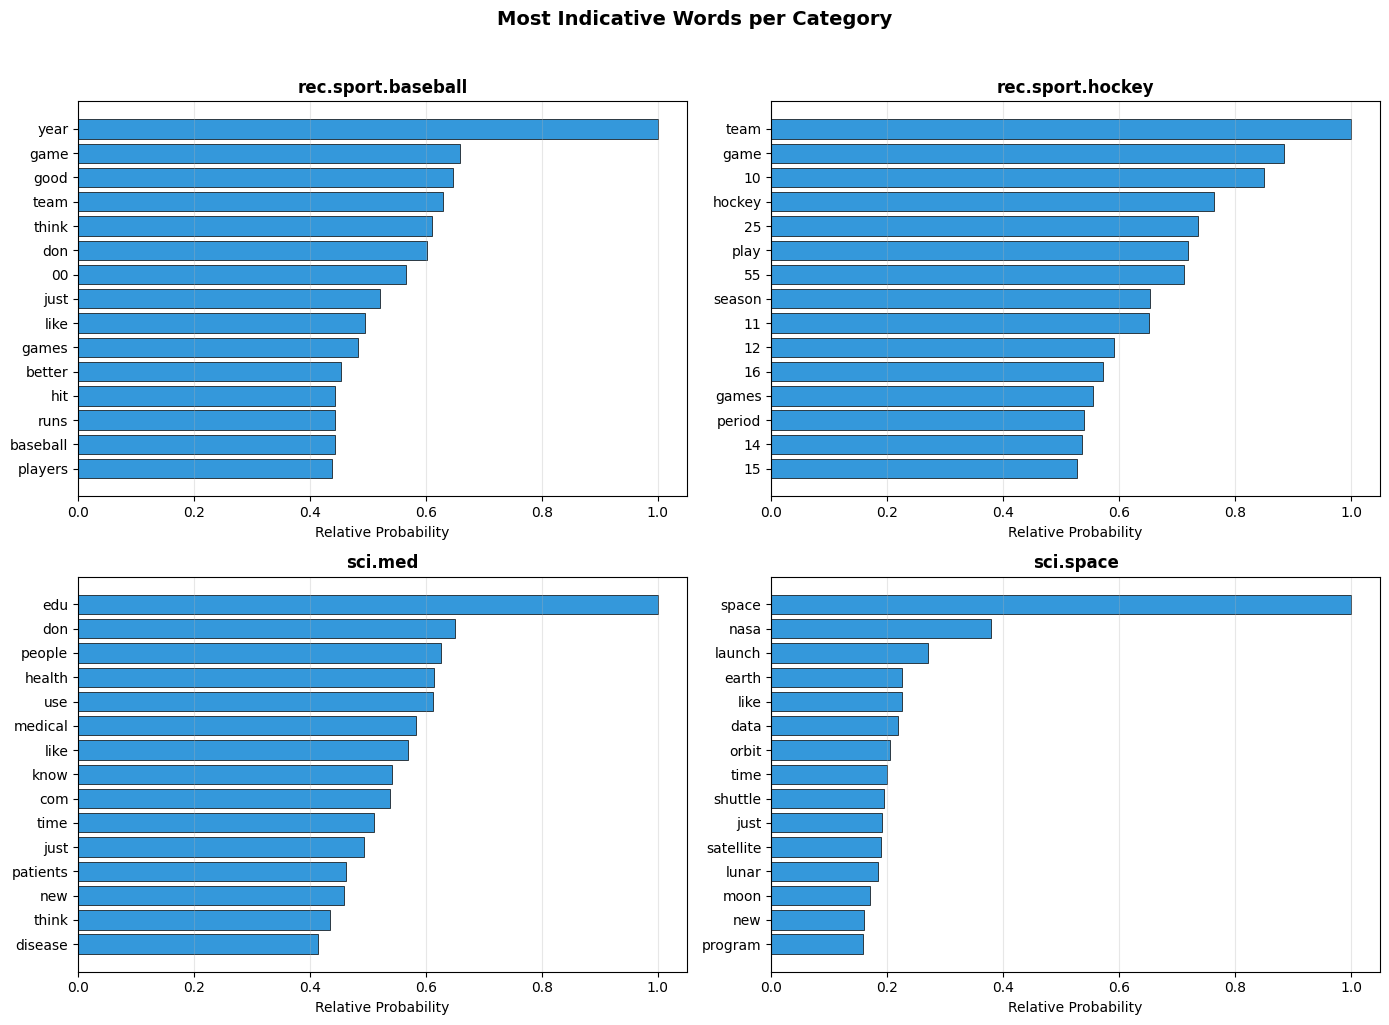

💡 These words make intuitive sense!
   - Baseball: game, team, players, runs, hit
   - Hockey: hockey, nhl, season, playoff
   - Medicine: medical, disease, patients, doctor
   - Space: space, nasa, orbit, launch, shuttle


In [17]:
# Train a model for feature analysis
mnb_news = MultinomialNB()
mnb_news.fit(X_train_counts, newsgroups_train.target)

# Get feature names
feature_names = np.array(count_vectorizer.get_feature_names_out())

# Find most important words for each class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (ax, category) in enumerate(zip(axes, newsgroups_train.target_names)):
    # Get log probabilities for this class
    log_probs = mnb_news.feature_log_prob_[idx]
    
    # Get top 15 words
    top_indices = np.argsort(log_probs)[-15:]
    top_words = feature_names[top_indices]
    top_probs = np.exp(log_probs[top_indices])  # Convert back from log
    
    # Normalize for visualization
    top_probs = top_probs / top_probs.max()
    
    ax.barh(range(len(top_words)), top_probs, color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words)
    ax.set_xlabel('Relative Probability', fontsize=10)
    ax.set_title(f'{category}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Most Indicative Words per Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 These words make intuitive sense!")
print("   - Baseball: game, team, players, runs, hit")
print("   - Hockey: hockey, nhl, season, playoff")
print("   - Medicine: medical, disease, patients, doctor")
print("   - Space: space, nasa, orbit, launch, shuttle")


## Part 10: Comparison with Other Classifiers

How does Naive Bayes compare to other classifiers in terms of accuracy and speed?


In [18]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Compare classifiers on 20 Newsgroups
classifiers = [
    ("Multinomial NB", MultinomialNB()),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Linear SVM", LinearSVC(max_iter=1000)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=20, random_state=CONFIG['seed'])),
    ("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=20, random_state=CONFIG['seed'], n_jobs=-1)),
]

print("Classifier Comparison on 20 Newsgroups (TF-IDF features)")
print("=" * 70)
print(f"{'Classifier':<25} {'Train Acc':<12} {'Test Acc':<12} {'Train Time':<12}")
print("-" * 70)

results = []
for name, clf in classifiers:
    start = time.time()
    clf.fit(X_train_tfidf, newsgroups_train.target)
    train_time = time.time() - start
    
    train_acc = clf.score(X_train_tfidf, newsgroups_train.target)
    test_acc = clf.score(X_test_tfidf, newsgroups_test.target)
    
    results.append({'name': name, 'train': train_acc, 'test': test_acc, 'time': train_time})
    print(f"{name:<25} {train_acc:<12.2%} {test_acc:<12.2%} {train_time:<12.3f}s")

print("=" * 70)


Classifier Comparison on 20 Newsgroups (TF-IDF features)
Classifier                Train Acc    Test Acc     Train Time  
----------------------------------------------------------------------
Multinomial NB            95.09%       88.46%       0.001       s
Logistic Regression       97.27%       86.82%       2.220       s
Linear SVM                97.86%       85.62%       0.034       s
Decision Tree             69.17%       57.12%       0.115       s
Random Forest             88.93%       79.51%       0.184       s


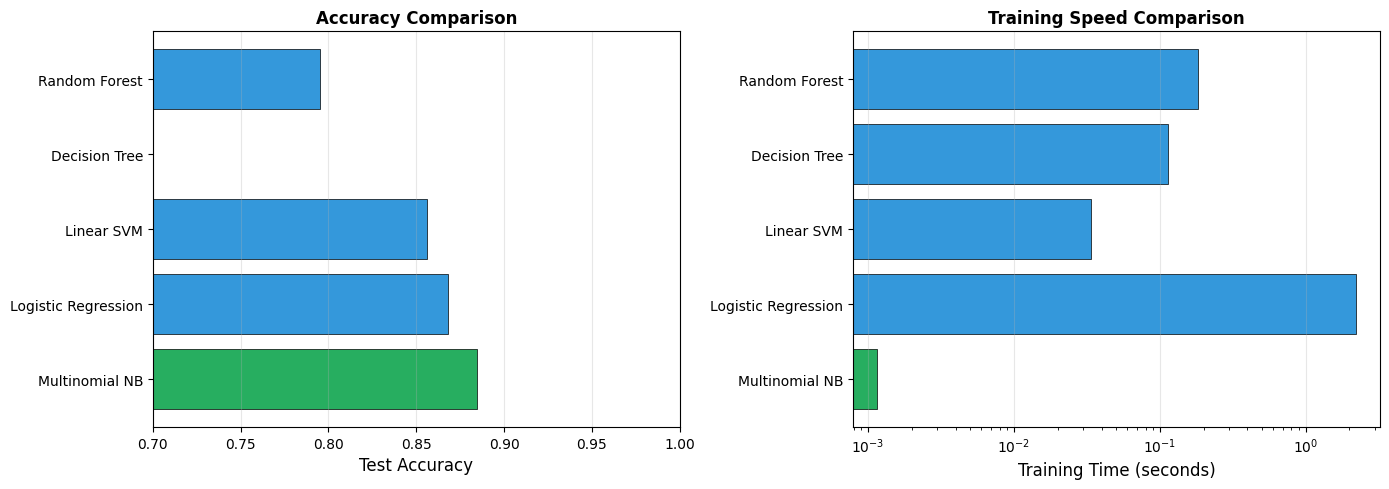

💡 Key Observations:
   • Naive Bayes is often the FASTEST classifier
   • Accuracy is competitive, especially for text data
   • Linear SVM and Logistic Regression often slightly outperform NB
   • NB is an excellent baseline and quick prototype


In [19]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [r['name'] for r in results]
test_accs = [r['test'] for r in results]
times = [r['time'] for r in results]

# Test Accuracy
colors = ['#27ae60' if 'NB' in n else '#3498db' for n in names]
axes[0].barh(names, test_accs, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Test Accuracy', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlim(0.7, 1.0)
axes[0].grid(True, alpha=0.3, axis='x')

# Training Time (log scale)
axes[1].barh(names, times, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Training Speed Comparison', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("💡 Key Observations:")
print("   • Naive Bayes is often the FASTEST classifier")
print("   • Accuracy is competitive, especially for text data")
print("   • Linear SVM and Logistic Regression often slightly outperform NB")
print("   • NB is an excellent baseline and quick prototype")


## Part 11: Practical Considerations

### When to Use Naive Bayes

| Use Case | Recommended Variant |
|----------|-------------------|
| Text classification (long docs) | Multinomial NB with TF-IDF |
| Text classification (short docs) | Bernoulli NB |
| Continuous features | Gaussian NB |
| Real-time / streaming | Any NB (fast incremental updates) |
| Baseline model | Any NB (quick to train and evaluate) |

### Advantages

1. **Extremely fast** — O(n·d) training, O(d) prediction
2. **Works with small data** — Doesn't need millions of samples
3. **Handles high dimensions** — Thousands of features is fine
4. **Probabilistic outputs** — Gives confidence scores
5. **Interpretable** — Can inspect feature probabilities
6. **Incremental learning** — Easy to update with new data

### Disadvantages

1. **Independence assumption** — Often violated in practice
2. **Can't learn feature interactions** — Unlike trees or neural networks
3. **Probability estimates are often wrong** — Rankings are usually correct
4. **Sensitive to irrelevant features** — No feature selection built-in
5. **Correlated features hurt performance** — Double-counting evidence


## Part 12: Key Takeaways

Congratulations! You now have deep intuitions about Naive Bayes classifiers.


In [20]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    KEY TAKEAWAYS                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. BAYES' THEOREM                                                ║
║     • P(class|features) ∝ P(features|class) × P(class)           ║
║     • Prior beliefs + evidence → posterior beliefs                ║
║                                                                   ║
║  2. THE "NAIVE" ASSUMPTION                                        ║
║     • Features are conditionally independent given the class      ║
║     • Almost always wrong, but often works anyway!                ║
║     • Simplifies computation from exponential to linear           ║
║                                                                   ║
║  3. THREE VARIANTS                                                ║
║     • Gaussian NB: continuous features (assumes normal dist)      ║
║     • Multinomial NB: count data (word frequencies)               ║
║     • Bernoulli NB: binary features (word presence/absence)       ║
║                                                                   ║
║  4. LAPLACE SMOOTHING                                             ║
║     • Prevents zero probabilities for unseen features             ║
║     • Add small count α to all feature counts                     ║
║     • α=1 is classic Laplace, α<1 is Lidstone                     ║
║                                                                   ║
║  5. PRACTICAL ADVICE                                              ║
║     • Use as baseline — fast to train and evaluate                ║
║     • Great for text classification (spam, sentiment, topics)     ║
║     • Works well even with thousands of features                  ║
║     • Don't trust probability estimates, just rankings            ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║                    KEY TAKEAWAYS                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. BAYES' THEOREM                                                ║
║     • P(class|features) ∝ P(features|class) × P(class)           ║
║     • Prior beliefs + evidence → posterior beliefs                ║
║                                                                   ║
║  2. THE "NAIVE" ASSUMPTION                                        ║
║     • Features are conditionally independent given the class      ║
║     • Almost always wrong, but often works anyway!                ║
║     • Simplifies computation from exponential to linear           ║
║                                                                   ║
║  3. THREE VARIANTS                                                ║
║     • Gaussian NB: c

### Summary Table

| Aspect | Key Points |
|--------|------------|
| **Foundation** | Bayes' theorem: update beliefs with evidence |
| **Key assumption** | Features are conditionally independent given class |
| **Variants** | Gaussian (continuous), Multinomial (counts), Bernoulli (binary) |
| **Smoothing** | Laplace smoothing prevents zero probabilities |
| **Complexity** | O(n·d) training, O(d) prediction — very fast! |
| **Best for** | Text classification, high-dimensional data, baselines |
| **Limitations** | Independence assumption, can't learn interactions |

### Reflection Questions

1. **Why** is the independence assumption called "naive"? When does it hurt performance?

2. **How** does Laplace smoothing work, and why is it essential for text classification?

3. **When** would you choose Multinomial NB over Bernoulli NB for text data?

4. **What** makes Naive Bayes particularly well-suited for spam filtering?

5. **Why** do the probability estimates from Naive Bayes tend to be poorly calibrated?

---

**Well done!** You now understand Naive Bayes classifiers — simple, fast, and surprisingly effective!

**Next up**: Explore **Decision Trees** to see a completely different approach to classification that can capture feature interactions.

---

## THE END

Check my repo for more **AI/ML** notebooks: https://github.com/tsilva/aiml-notebooks
